# Ejercicio MongoDB - Regresión Lineal Simple

Este notebook muestra cómo trabajar con MongoDB y aplicar regresión lineal simple.

## Instalación de librerías

```bash
pip install pymongo scikit-learn
```

## 1. Generar archivo JSON con datos de ventas

In [1]:
import json

# Datos de ventas - 50 registros con variables numéricas
# Fields: precio, gasto_publicidad, visitantes, unidades_vendidas
datos_ventas = [
  {"precio": 50, "gasto_publicidad": 200, "visitantes": 1200, "unidades_vendidas": 85},
  {"precio": 55, "gasto_publicidad": 250, "visitantes": 1500, "unidades_vendidas": 102},
  {"precio": 45, "gasto_publicidad": 180, "visitantes": 900, "unidades_vendidas": 62},
  {"precio": 60, "gasto_publicidad": 300, "visitantes": 1800, "unidades_vendidas": 118},
  {"precio": 48, "gasto_publicidad": 190, "visitantes": 1100, "unidades_vendidas": 78},
  {"precio": 52, "gasto_publicidad": 220, "visitantes": 1300, "unidades_vendidas": 91},
  {"precio": 58, "gasto_publicidad": 280, "visitantes": 1700, "unidades_vendidas": 110},
  {"precio": 42, "gasto_publicidad": 150, "visitantes": 800, "unidades_vendidas": 55},
  {"precio": 65, "gasto_publicidad": 350, "visitantes": 2000, "unidades_vendidas": 130},
  {"precio": 47, "gasto_publicidad": 175, "visitantes": 1000, "unidades_vendidas": 70},
  {"precio": 53, "gasto_publicidad": 230, "visitantes": 1400, "unidades_vendidas": 95},
  {"precio": 44, "gasto_publicidad": 165, "visitantes": 850, "unidades_vendidas": 58},
  {"precio": 62, "gasto_publicidad": 320, "visitantes": 1900, "unidades_vendidas": 125},
  {"precio": 49, "gasto_publicidad": 195, "visitantes": 1150, "unidades_vendidas": 80},
  {"precio": 56, "gasto_publicidad": 260, "visitantes": 1600, "unidades_vendidas": 105},
  {"precio": 43, "gasto_publicidad": 160, "visitantes": 820, "unidades_vendidas": 56},
  {"precio": 59, "gasto_publicidad": 290, "visitantes": 1750, "unidades_vendidas": 115},
  {"precio": 46, "gasto_publicidad": 170, "visitantes": 950, "unidades_vendidas": 66},
  {"precio": 54, "gasto_publicidad": 240, "visitantes": 1450, "unidades_vendidas": 98},
  {"precio": 41, "gasto_publicidad": 145, "visitantes": 780, "unidades_vendidas": 52},
  {"precio": 66, "gasto_publicidad": 360, "visitantes": 2100, "unidades_vendidas": 135},
  {"precio": 51, "gasto_publicidad": 210, "visitantes": 1250, "unidades_vendidas": 88},
  {"precio": 57, "gasto_publicidad": 270, "visitantes": 1650, "unidades_vendidas": 108},
  {"precio": 45, "gasto_publicidad": 185, "visitantes": 920, "unidades_vendidas": 64},
  {"precio": 63, "gasto_publicidad": 330, "visitantes": 1950, "unidades_vendidas": 128},
  {"precio": 48, "gasto_publicidad": 190, "visitantes": 1080, "unidades_vendidas": 75},
  {"precio": 55, "gasto_publicidad": 250, "visitantes": 1520, "unidades_vendidas": 100},
  {"precio": 44, "gasto_publicidad": 170, "visitantes": 870, "unidades_vendidas": 60},
  {"precio": 61, "gasto_publicidad": 310, "visitantes": 1850, "unidades_vendidas": 122},
  {"precio": 47, "gasto_publicidad": 180, "visitantes": 1030, "unidades_vendidas": 72},
  {"precio": 53, "gasto_publicidad": 235, "visitantes": 1420, "unidades_vendidas": 96},
  {"precio": 42, "gasto_publicidad": 155, "visitantes": 810, "unidades_vendidas": 54},
  {"precio": 64, "gasto_publicidad": 340, "visitantes": 1980, "unidades_vendidas": 132},
  {"precio": 50, "gasto_publicidad": 200, "visitantes": 1180, "unidades_vendidas": 82},
  {"precio": 56, "gasto_publicidad": 265, "visitantes": 1580, "unidades_vendidas": 104},
  {"precio": 43, "gasto_publicidad": 162, "visitantes": 840, "unidades_vendidas": 57},
  {"precio": 60, "gasto_publicidad": 300, "visitantes": 1780, "unidades_vendidas": 117},
  {"precio": 46, "gasto_publicidad": 175, "visitantes": 970, "unidades_vendidas": 68},
  {"precio": 54, "gasto_publicidad": 245, "visitantes": 1480, "unidades_vendidas": 99},
  {"precio": 41, "gasto_publicidad": 148, "visitantes": 790, "unidades_vendidas": 53},
  {"precio": 67, "gasto_publicidad": 370, "visitantes": 2150, "unidades_vendidas": 138},
  {"precio": 52, "gasto_publicidad": 215, "visitantes": 1280, "unidades_vendidas": 90},
  {"precio": 58, "gasto_publicidad": 285, "visitantes": 1720, "unidades_vendidas": 112},
  {"precio": 45, "gasto_publicidad": 182, "visitantes": 910, "unidades_vendidas": 63},
  {"precio": 62, "gasto_publicidad": 325, "visitantes": 1920, "unidades_vendidas": 126},
  {"precio": 49, "gasto_publicidad": 193, "visitantes": 1120, "unidades_vendidas": 77},
  {"precio": 55, "gasto_publicidad": 255, "visitantes": 1540, "unidades_vendidas": 101},
  {"precio": 44, "gasto_publicidad": 168, "visitantes": 860, "unidades_vendidas": 59},
  {"precio": 63, "gasto_publicidad": 335, "visitantes": 1960, "unidades_vendidas": 129}
]

# Guardar en archivo JSON
with open('ventas.json', 'w', encoding='utf-8') as f:
    json.dump(datos_ventas, f, ensure_ascii=False, indent=2)

print(f"Archivo 'ventas.json' creado con {len(datos_ventas)} registros")

Archivo 'ventas.json' creado con 49 registros


## 2. Importar datos a MongoDB

In [4]:
import json
from pymongo import MongoClient

# Cargar datos del archivo JSON
with open('ventas.json', 'r', encoding='utf-8') as f:
    datos_ventas = json.load(f)

# Conectar a MongoDB
client = MongoClient('mongodb://localhost:27017/')
db = client['empresas'] # Colocar aquí tu base de datos
coleccion = db['ventas'] # Coolocar aquí tu colección

# Insertar los documentos
coleccion.insert_many(datos_ventas)

print(f"Se insertaron {len(datos_ventas)} documentos en la colección 'ventas'")

client.close()

Se insertaron 49 documentos en la colección 'ventas'


## 3. Teoría: Regresión Lineal Simple

La **regresión lineal simple** modela la relación entre dos variables:

- **Variable independiente (X)**: La que usamos para predecir. Ejemplo: `gasto_publicidad`
- **Variable dependiente (y)**: La que queremos predecir. Ejemplo: `unidades_vendidas`

**Fórmula**: `y = β₀ + β₁ * x`

- `β₀` (intercepto): Valor de y cuando x = 0
- `β₁` (pendiente): Cambio en y por cada unidad de cambio en x

**División de datos**:
- **Entrenamiento (80%)**: Datos para entrenar el modelo
- **Prueba (20%)**: Datos para evaluar el modelo

**Métricas**:
- **MSE** (Error Cuadrático Medio): Error promedio al cuadrado. Mientras menor, mejor.
- **R²** (Coeficiente de determinación): Porcentaje de varianza explicada. Mayor es mejor (máximo 1).

## 4. Cargar datos desde MongoDB

In [11]:
from pymongo import MongoClient
import pandas as pd

# Conectar a MongoDB
client = MongoClient('mongodb://localhost:27017/')
db = client['empresas'] # Colocar aquí tu base de datos
coleccion = db['ventas'] # Coolocar aquí tu colección

# Obtener todos los documentos: coleccion.find()
# Sintaxis: coleccion.find(filtro, proyección)
# - Sin filtro = todos los documentos
# - returns cursor (convertir a lista con list())
documentos = list(coleccion.find())
client.close()

# Convertir a DataFrame
df = pd.DataFrame(documentos)


# Eliminar campo _id de MongoDB
if '_id' in df.columns:
    df = df.drop('_id', axis=1)

print("Datos de Ventas:")
display(df.head())
print(f"Total registros: {len(df)}")



Datos de Ventas:


,precio,gasto_publicidad,visitantes,unidades_vendidas
0,50,200,1200,85
1,55,250,1500,102
2,45,180,900,62
3,60,300,1800,118
4,48,190,1100,78


Total registros: 49


## 5. Dividir datos - train_test_split()

**Sintaxis**: `train_test_split(X, y, test_size, random_state)`

**Parámetros**:
- `X`: Variable(s) independiente(s)
- `y`: Variable dependiente
- `test_size`: Proporción para prueba (0.2 = 20%)
- `random_state`: Semilla para reproducibilidad

**Retorna**: 4 arrays: (X_train, X_test, y_train, y_test)

In [14]:
from sklearn.model_selection import train_test_split

# Definir variables
X = df[['gasto_publicidad']]  # DataFrame (independiente)
y = df['unidades_vendidas']   # Series (dependiente)

print("X (independiente): gasto_publicidad")
print("y (dependiente): unidades_vendidas")

# Dividir: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,   # 20% para prueba
    random_state=42   # Reproducibilidad
)

print(f"\nEntrenamiento: {len(X_train)} registros")
print(f"Prueba: {len(X_test)} registros")

X (independiente): gasto_publicidad
y (dependiente): unidades_vendidas

Entrenamiento: 39 registros
Prueba: 10 registros


## 6. Entrenar modelo - LinearRegression() y fit()

**LinearRegression()**:
- Crea un modelo de regresión lineal

**fit(X_train, y_train)**:
- Entrena el modelo con los datos
- Ajusta coeficientes para minimizar error
- Retorna: self (modelo entrenado)

**Atributos después de fit()**:
- `coef_`: Coeficiente(s) (β₁)
- `intercept_`: Intercepto (β₀)

In [19]:
from sklearn.linear_model import LinearRegression

# Crear modelo
modelo = LinearRegression()

# Entrenar: fit(X_train, y_train)
modelo.fit(X_train, y_train)

print("Modelo entrenado")
print(f"Coeficiente (β₁): {modelo.coef_[0]:.4f}")
print(f"Intercepto (β₀): {modelo.intercept_:.4f}")
print(f"\nEcuación: y = {modelo.intercept_:.4f} + {modelo.coef_[0]:.4f} * x")

Modelo entrenado
Coeficiente (β₁): 0.3924
Intercepto (β₀): -0.5918

Ecuación: y = -0.5918 + 0.3924 * x


## 7. Evaluar modelo - predict(), MSE y R²

**predict(X)**:
- Predice valores de y para datos dados
- Sintaxis: modelo.predict([[valor]])

**mean_squared_error(y_true, y_pred)**:
- MSE = (1/n) * Σ(y_true - y_pred)²
- 0 = perfecto, mayor = peor

**r2_score(y_true, y_pred)**:
- R² = 1 - (SS_res / SS_tot)
- 1 = perfecto, 0 = media, <0 = peor que media

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

# Predicciones
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Métricas de entrenamiento
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Métricas de prueba
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("=" * 40)
print("EVALUACIÓN")
print("=" * 40)

print("\nEntrenamiento:")
print(f"  MSE: {mse_train:.4f}")
print(f"  R² : {r2_train:.4f} ({r2_train*100:.1f}%)")

print("\nPrueba:")
print(f"  MSE: {mse_test:.4f}")
print(f"  R² : {r2_test:.4f} ({r2_test*100:.1f}%)")

EVALUACIÓN

Entrenamiento:
  MSE: 20.0662
  R² : 0.9694 (96.9%)

Prueba:
  MSE: 16.2912
  R² : 0.9660 (96.6%)


## 8. Visualización - matplotlib

**Funciones principales**:
- `plt.figure(figsize)`: Crear figura
- `plt.scatter(x, y)`: Gráfico de puntos
- `plt.plot(x, y)`: Línea
- `plt.xlabel()`, `plt.ylabel()`: Etiquetas
- `plt.title()`: Título
- `plt.legend()`: Leyenda
- `plt.grid()`: Cuadrícula
- `plt.show()`: Mostrar

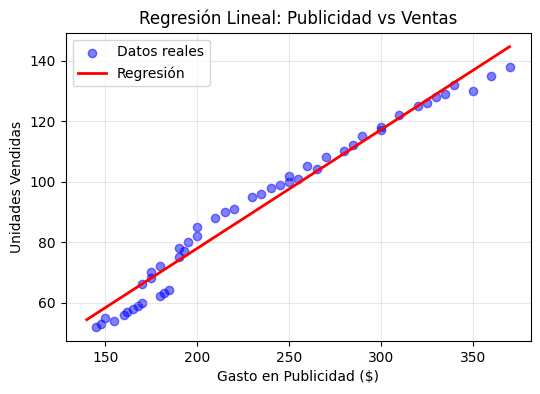

In [27]:
import matplotlib.pyplot as plt

# Crear figura
plt.figure(figsize=(6, 4))

# Puntos de datos reales
plt.scatter(X, y, color='blue', alpha=0.5, label='Datos reales')

# Línea de regresión
X_linea = pd.DataFrame({'gasto_publicidad': range(140, 380, 10)})
y_linea = modelo.predict(X_linea)
plt.plot(X_linea, y_linea, color='red', linewidth=2, label='Regresión')

# Etiquetas
plt.xlabel('Gasto en Publicidad ($)')
plt.ylabel('Unidades Vendidas')
plt.title('Regresión Lineal: Publicidad vs Ventas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Predicción con nuevos valores

Una vez entrenado el modelo, podemos predecir para valores que NO estaban en los datos originales.

**Importante**: El valor debe pasarse como lista 2D: `[[valor]]`

In [30]:
import scipy.stats as stats
# Predicción: cuánto venderíamos con $400 de publicidad?
gasto_nuevo = 400 # Cambiar según lo que se quiere invertir en publicidad
prediccion = modelo.predict([[gasto_nuevo]])

print("=" * 40)
print("PREDICCIÓN")
print("=" * 40)
print(f"\nGasto en publicidad: ${gasto_nuevo}")
print(f"Unidades vendidas (predicción): {prediccion[0]:.2f}")

# Más ejemplos
print("\nOtros ejemplos:")
for gasto in [150, 250, 350]: # Cambiar o añadir cantidades en publicidad
    pred = modelo.predict([[gasto]])[0]
    print(f"  ${gasto} → {pred:.2f} unidades")

pearson = df.select_dtypes(include=['number']).corr(method='pearson')
print("Matriz de correlación (Pearson):")
display(pearson)


PREDICCIÓN

Gasto en publicidad: $400
Unidades vendidas (predicción): 156.35

Otros ejemplos:
  $150 → 58.26 unidades
  $250 → 97.50 unidades
  $350 → 136.73 unidades
Matriz de correlación (Pearson):


/home/a/Downloads/CienciaDeDatos/myvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/a/Downloads/CienciaDeDatos/myvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/a/Downloads/CienciaDeDatos/myvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/a/Downloads/CienciaDeDatos/myvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,precio,gasto_publicidad,visitantes,unidades_vendidas
precio,1.000000,0.991895,0.997039,0.997446
gasto_publicidad,0.991895,1.000000,0.991721,0.986056
visitantes,0.997039,0.991721,1.000000,0.997675
unidades_vendidas,0.997446,0.986056,0.997675,1.000000
